## Tarea 3 - Análisis de Texto
### Jessica Lizeth Hernández Bracho -1842553

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

In [7]:
# Dataset oficial usando solo 2 categorías competitivas
categorias = ['rec.autos', 'sci.space']
datos_raw = fetch_20newsgroups(subset='all', categories=categorias, remove=('headers', 'footers', 'quotes'))

In [8]:
df = pd.DataFrame({'text': datos_raw.data, 'target': datos_raw.target})
df['label'] = df['target'].map({0: 'autos', 1: 'space'})
df.drop(['target'], axis=1, inplace=True)

In [9]:
# Limpieza (textos vacíos al quitar encabezados)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)

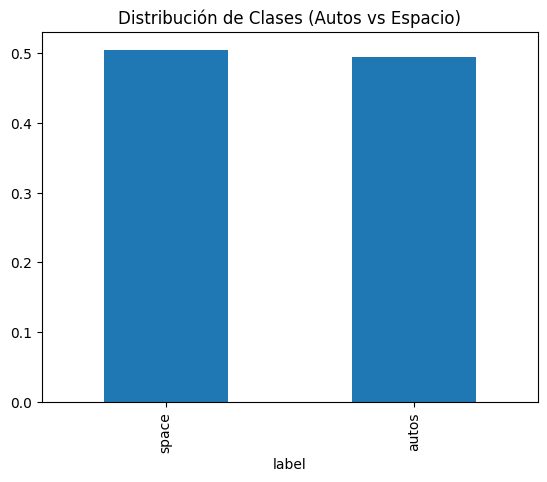

In [10]:
# Distribución de clases
df['label'].value_counts(normalize = True).plot.bar()
plt.title('Distribución de Clases (Autos vs Espacio)')
plt.show()

## Conteo de palabras

In [11]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
display(df.head())

print('autos', df[df['label'] == 'autos']['word_count'].describe())
print('space', df[df['label'] == 'space']['word_count'].describe())

,text,label,word_count
0,.. \n\nThese seem hardly like the groups to di...,space,104
1,It's been a while since I've reviewed a car bu...,autos,1651
2,\n\nnice theory. too bad the MR2's never came...,autos,53
3,\nIt was more than a theoretical concept; it w...,space,101
4,"My wife and I looked at, and drove one last fa...",autos,117


autos count     937.000000
mean      119.531483
std       221.180968
min         1.000000
25%        40.000000
50%        76.000000
75%       136.000000
max      4387.000000
Name: word_count, dtype: float64
space count     955.000000
mean      196.271204
std       502.949765
min         1.000000
25%        45.000000
50%        89.000000
75%       171.000000
max      9113.000000
Name: word_count, dtype: float64


## Conteo de caracteres

In [12]:
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
print('autos', df[df['label'] == 'autos']['char_count'].describe())
print('space', df[df['label'] == 'space']['char_count'].describe())

autos count      937.000000
mean       692.217716
std       1342.461936
min          5.000000
25%        226.000000
50%        435.000000
75%        775.000000
max      27257.000000
Name: char_count, dtype: float64
space count      955.000000
mean      1253.260733
std       3367.817965
min          8.000000
25%        279.500000
50%        522.000000
75%       1029.000000
max      56793.000000
Name: char_count, dtype: float64


## Densidad de palabras

In [13]:
df['word_density'] = df['char_count'] / df['word_count']
display(df.head())

,text,label,word_count,char_count,word_density
0,.. \n\nThese seem hardly like the groups to di...,space,104,587,5.644231
1,It's been a while since I've reviewed a car bu...,autos,1651,9268,5.613568
2,\n\nnice theory. too bad the MR2's never came...,autos,53,312,5.886792
3,\nIt was more than a theoretical concept; it w...,space,101,541,5.356436
4,"My wife and I looked at, and drove one last fa...",autos,117,653,5.581197


## Representación gráfica

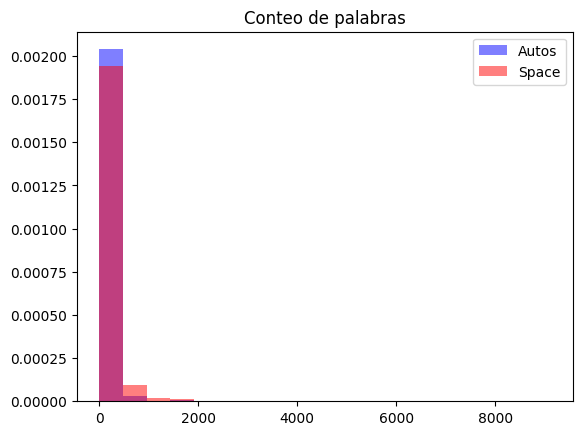

In [27]:
df_autos = df[df['label'] == 'autos']
df_space = df[df['label'] == 'space']

plt.figure()
plt.title('Conteo de palabras')
bins = np.linspace(np.min(df['word_count']), np.max(df['word_count']), 20)
plt.hist(df_autos['word_count'],  label = 'Autos', bins = bins, color = 'blue', alpha = 0.5, density = True)
plt.hist(df_space['word_count'],  label = 'Space', bins = bins, color = 'red', alpha = 0.5, density = True)
plt.legend()
plt.show()

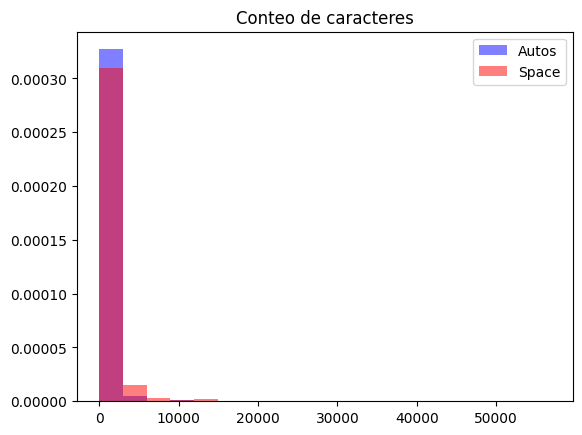

In [28]:
plt.figure()
plt.title('Conteo de caracteres')
bins = np.linspace(np.min(df['char_count']), np.max(df['char_count']), 20)
plt.hist(df_autos['char_count'],  label = 'Autos', bins = bins, color = 'blue', alpha = 0.5, density = True)
plt.hist(df_space['char_count'],  label = 'Space', bins = bins, color = 'red', alpha = 0.5, density = True)
plt.legend()
plt.show()

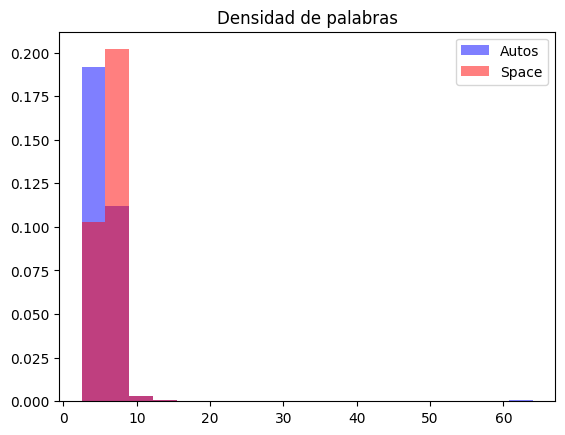

In [16]:
plt.figure()
plt.title('Densidad de palabras')
bins = np.linspace(np.min(df['word_density']), np.max(df['word_density']), 20)
plt.hist(df_autos['word_density'],  label = 'Autos', bins = bins, color = 'blue', alpha = 0.5, density = True)
plt.hist(df_space['word_density'],  label = 'Space', bins = bins, color = 'red', alpha = 0.5, density = True)
plt.legend()
plt.show()

## Limpieza y Lematización (Con WordNet)

In [17]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
text = list(df['text'])
lemmatizer = WordNetLemmatizer()
corpus = []

for i in range(len(text)):
    r = re.sub('[^a-zA-Z]', ' ', text[i])
    r = r.lower()
    r = r.split()
    r = [word for word in r if word not in stopwords.words('english')]
    r = [lemmatizer.lemmatize(word) for word in r]
    r = ' '.join(r)
    corpus.append(r)

df['text_clean'] = corpus
display(df.head())

,text,label,word_count,char_count,word_density,text_clean
0,.. \n\nThese seem hardly like the groups to di...,space,104,587,5.644231,seem hardly like group discus huh legitimate p...
1,It's been a while since I've reviewed a car bu...,autos,1651,9268,5.613568,since reviewed car today paid visit old friend...
2,\n\nnice theory. too bad the MR2's never came...,autos,53,312,5.886792,nice theory bad mr never came four cylinder li...
3,\nIt was more than a theoretical concept; it w...,space,101,541,5.356436,theoretical concept seriously pursued freeman ...
4,"My wife and I looked at, and drove one last fa...",autos,117,653,5.581197,wife looked drove one last fall model wayyyyyy...


## Entrenamiento y prueba

In [19]:
X = df['text_clean']
y = df['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

print('Training Data :', X_train.size)
print('Testing Data : ', X_test.size)

Training Data : 1513
Testing Data :  379


## Vectorización

In [20]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
# Conteo de palabras
count_vect = CountVectorizer(analyzer='word')
count_vect.fit(X_train)
xtrain_count = count_vect.transform(X_train)
xtest_count = count_vect.transform(X_test)

In [22]:
# Palabras
tfidf_vect = TfidfVectorizer(analyzer='word')
xtrain_tfidf = tfidf_vect.fit_transform(X_train)
xtest_tfidf = tfidf_vect.transform(X_test)

In [23]:
# N-gramas
tfidf_vect_ngram = TfidfVectorizer(analyzer='word', ngram_range=(2,3))
xtrain_tfidf_ngram = tfidf_vect_ngram.fit_transform(X_train)
xtest_tfidf_ngram = tfidf_vect_ngram.transform(X_test)

In [24]:
# Caracteres
tfidfvect_ngramchars = TfidfVectorizer(analyzer='char')
xtrain_tfidf_ngramchars = tfidfvect_ngramchars.fit_transform(X_train)
xtest_tfidf_ngramchars = tfidfvect_ngramchars.transform(X_test)

## Modelos

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [26]:
# Modelo base
lr = LogisticRegression(max_iter=1000)

In [29]:
# Lista de combinaciones de datos vectorizados
pares = [
    ('conteo', xtrain_count, xtest_count),
    ('palabras', xtrain_tfidf, xtest_tfidf),
    ('ngramas', xtrain_tfidf_ngram, xtest_tfidf_ngram),
    ('caracteres', xtrain_tfidf_ngram_chars, xtest_tfidf_ngram_chars)
]

valores_C = [0.1, 1.0, 10.0]

In [31]:
print("RESULTADOS DEL DISEÑO DE EXPERIMENTOS \n")

for nombre_estrategia, x_train_v, x_test_v in pares:
    print(f" Estrategia: {nombre_estrategia.upper()} ")
    for c in valores_C:
        # Ajuste del hiperparámetro C en cada experimento
        lr.set_params(C=c)
        lr.fit(x_train_v, y_train)

        predictions = lr.predict(x_test_v)

        # Exactitud global (Accuracy)
        acc = metrics.accuracy_score(y_test, predictions)

        # Matriz de confusión
        df_confusion = pd.DataFrame(
            metrics.confusion_matrix(y_test, predictions, labels=['autos', 'space']),
            index=['autos', 'space'],
            columns=['autos_pred', 'space_pred']
        )

        print(f"Hiperparámetro C: {c} | Exactitud (Accuracy): {acc:.4f}")
        print(df_confusion)
        print("-" * 55)
    print("\n")

RESULTADOS DEL DISEÑO DE EXPERIMENTOS 

 Estrategia: CONTEO 
Hiperparámetro C: 0.1 | Exactitud (Accuracy): 0.9420
       autos_pred  space_pred
autos         185          12
space          10         172
-------------------------------------------------------
Hiperparámetro C: 1.0 | Exactitud (Accuracy): 0.9420
       autos_pred  space_pred
autos         185          12
space          10         172
-------------------------------------------------------
Hiperparámetro C: 10.0 | Exactitud (Accuracy): 0.9103
       autos_pred  space_pred
autos         178          19
space          15         167
-------------------------------------------------------


 Estrategia: PALABRAS 
Hiperparámetro C: 0.1 | Exactitud (Accuracy): 0.9129
       autos_pred  space_pred
autos         167          30
space           3         179
-------------------------------------------------------
Hiperparámetro C: 1.0 | Exactitud (Accuracy): 0.9472
       autos_pred  space_pred
autos         182          15
spac